# Загружаем почищенные данные

### Импорт библиотек


In [3]:
import pandas as pd
import re
from langchain.text_splitter import RecursiveCharacterTextSplitter

In [6]:
# Загружаем файл
df = pd.read_csv(r"C:\Users\smirn\Downloads\Telegram Desktop\ikanam_publications.csv")

# Посмотрим на колонки и первые несколько строк
print(df.columns)
print(df.head(3))

Index(['post_date', 'post_id', 'post_source', 'post_text', 'comment_text'], dtype='object')
             post_date post_id                      post_source  \
0  2016-10-08 21:52:07       1  https://vk.com/wall-130344439_1   
1  2016-10-09 21:53:07       2  https://vk.com/wall-130344439_2   
2  2016-10-09 22:08:21       5  https://vk.com/wall-130344439_5   

                                           post_text  \
0                               Пост состоит из фото   
1                               Пост состоит из фото   
2  Сегодня последний день регистрации на киллера....   

                                        comment_text  
0                       ['К посту комментариев нет']  
1  ['пикчер - бог', 'id6045249Philip,', 'В голос!...  
2                       ['К посту комментариев нет']  


In [7]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

# Создаем сплиттер с параметрами
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=400,        # максимальный размер чанка в символах
    chunk_overlap=50,      # перекрытие между чанками
    separators=["\n\n", "\n", ".", "!", "?", ",", " ", ""]  # разделители для деления текста
)


In [8]:
import pandas as pd
import re

# Функция очистки текста чанков
def clean_chunk_text(text):
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'([!?.,])\1{2,}', r'\1', text)
    text = re.sub(r'[^\w\s.,!?-]', '', text)
    return text

rows = []

for idx, row in df.iterrows():
    doc_id = row['post_id']
    source = row['post_source']
    date = row['post_date']
    title = f"Post {doc_id} ({date})"

    # Обрабатываем основной пост
    post_text = str(row['post_text']) if pd.notna(row['post_text']) else ""
    if post_text.strip():
        post_chunks = text_splitter.split_text(post_text)
        for i, chunk in enumerate(post_chunks):
            cleaned = clean_chunk_text(chunk)
            if len(cleaned) < 50:
                continue
            rows.append({
                'document_id': doc_id,
                'chunk_id': i,
                'title': title,
                'chunk_text': cleaned,
                'source': source,
                'comment': 'пост'
            })

    # Обрабатываем комментарии
    comment_text = str(row['comment_text']) if pd.notna(row['comment_text']) else ""
    if comment_text.strip():
        comment_chunks = text_splitter.split_text(comment_text)
        for i, chunk in enumerate(comment_chunks):
            cleaned = clean_chunk_text(chunk)
            if len(cleaned) < 50:
                continue
            rows.append({
                'document_id': doc_id,
                'chunk_id': i,
                'title': title,
                'chunk_text': cleaned,
                'source': source,
                'comment': 'комментарий'
            })

# Создаем итоговый DataFrame с чанками
df_chunks = pd.DataFrame(rows)

# Сохраняем в CSV
df_chunks.to_csv('ikanam_chunks.csv', index=False)

print(f"Всего чанков получено: {len(df_chunks)}")
print("Результат сохранён в файл ikanam_chunks.csv")


Всего чанков получено: 2816
Результат сохранён в файл ikanam_chunks.csv


# Предварительный анализ чанков

Уникальных документов: 851
Всего чанков: 2816


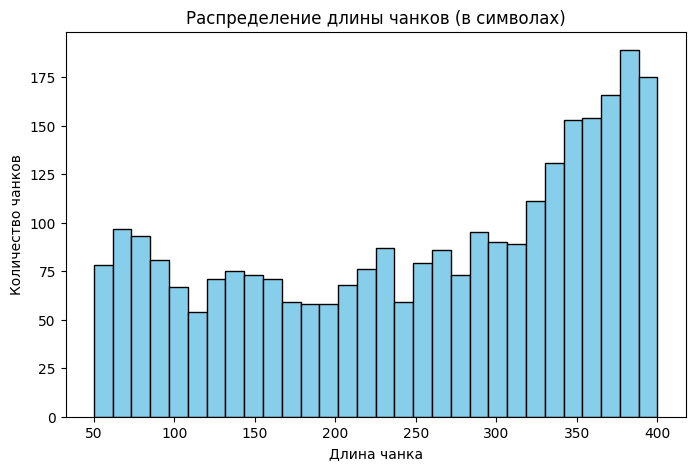

Типы чанков (посты / комментарии):
comment
пост           2202
комментарий     614
Name: count, dtype: int64


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Загружаем файл с чанками
df_chunks = pd.read_csv('ikanam_chunks.csv')

# 1. Сколько уникальных документов (post_id)
num_docs = df_chunks['document_id'].nunique()
print(f"Уникальных документов: {num_docs}")

# 2. Общее количество чанков
num_chunks = len(df_chunks)
print(f"Всего чанков: {num_chunks}")

# 3. Добавим колонку с длиной чанка (число символов)
df_chunks['chunk_len'] = df_chunks['chunk_text'].str.len()

# 4. Распределение длины чанков — построим гистограмму
plt.figure(figsize=(8,5))
plt.hist(df_chunks['chunk_len'], bins=30, color='skyblue', edgecolor='black')
plt.title('Распределение длины чанков (в символах)')
plt.xlabel('Длина чанка')
plt.ylabel('Количество чанков')
plt.show()

# 5. Сколько у нас постов и комментариев
counts = df_chunks['comment'].value_counts()
print("Типы чанков (посты / комментарии):")
print(counts)


In [10]:
# pip install sentence-transformers faiss-cpu

# Код для построения эмбеддингов и индекса FAISS

In [11]:
import pandas as pd
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

df = pd.read_csv('ikanam_chunks.csv')
texts = df['chunk_text'].tolist()

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(texts, show_progress_bar=True, convert_to_numpy=True)

dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(embeddings)

faiss.write_index(index, 'ikanam_faiss.index')
np.save('ikanam_embeddings.npy', embeddings)
df.to_csv('ikanam_chunks.csv', index=False)


C:\Users\smirn\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 88/88 [02:13<00:00,  1.52s/it]
